# Analisa dari tahun 2017-2024
Jocelyn Lualdi C14230097

## Import & Configuration

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

## Load Data, Preprocess, Merge with Genre
- Ambil data dari dataset judul x genre
- Merge semua data dari 2017-2024
- Join kedua data itu berdasarkan judul

In [45]:
def load_and_clean_data():
    # Load Judul X Genre
    try:
        buku_df = pd.read_csv('buku.csv')
        buku_df['Judul_clean'] = buku_df['Judul'].astype(str).str.lower().str.strip()
    except:
        print("CRITICAL: buku.csv not found.")
        return None

    # Load Sales
    files = sorted(glob.glob('Penjualan 20*.xlsx') + glob.glob('Penjualan 20*.csv'))
    all_sales = []

    for f in files:
        try:
            if f.endswith('.xlsx'): df_temp = pd.read_excel(f, skiprows=4)
            else: df_temp = pd.read_csv(f, skiprows=4)

            df_temp = df_temp.dropna(subset=['No. Trans.', 'Judul'], how='any')
            df_temp = df_temp[pd.to_datetime(df_temp['Tgl. Trans.'], errors='coerce').notna()]
            all_sales.append(df_temp)
        except Exception as e:
            print(f"Skipped {f}: {e}")

    if not all_sales: return None

    combined = pd.concat(all_sales, ignore_index=True)

    # Merge Genres
    combined['Judul_clean'] = combined['Judul'].astype(str).str.lower().str.strip()
    final_df = combined.merge(buku_df[['Judul_clean', 'Genre']], on='Judul_clean', how='left')
    final_df['Genre'] = final_df['Genre'].fillna('Unknown')

    # Type Conversion & Filtering
    final_df['Tgl. Trans.'] = pd.to_datetime(final_df['Tgl. Trans.'])
    for col in ['Total (Rp)', 'Grand Total (Rp)', 'Jml', 'Total Disc (%)']:
        final_df[col] = pd.to_numeric(final_df[col], errors='coerce').fillna(0)

    # Remove Returns (Negative Sales) for Analysis
    final_df = final_df[final_df['Total (Rp)'] >= 0]

    print(f"Data Loaded: {len(final_df)} clean transactions.")
    return final_df

df = load_and_clean_data()

Data Loaded: 28684 clean transactions.


## Top Genres Based on Holidays
Holiday itu kapan, bulan apa tanggal apa

In [46]:
if df is not None:
    df['Month'] = df['Tgl. Trans.'].dt.month
    df['Day'] = df['Tgl. Trans.'].dt.day

    def get_holiday(row):
        m, d = row['Month'], row['Day']
        if m == 7 and 1 <= d <= 10: return 'Anniversary (July 1-10)'
        if m == 12: return 'Christmas/YearEnd'
        if m in [3, 4]: return 'Easter Period'
        return 'Regular Period'

    df['Holiday'] = df.apply(get_holiday, axis=1)

Pie chart nya

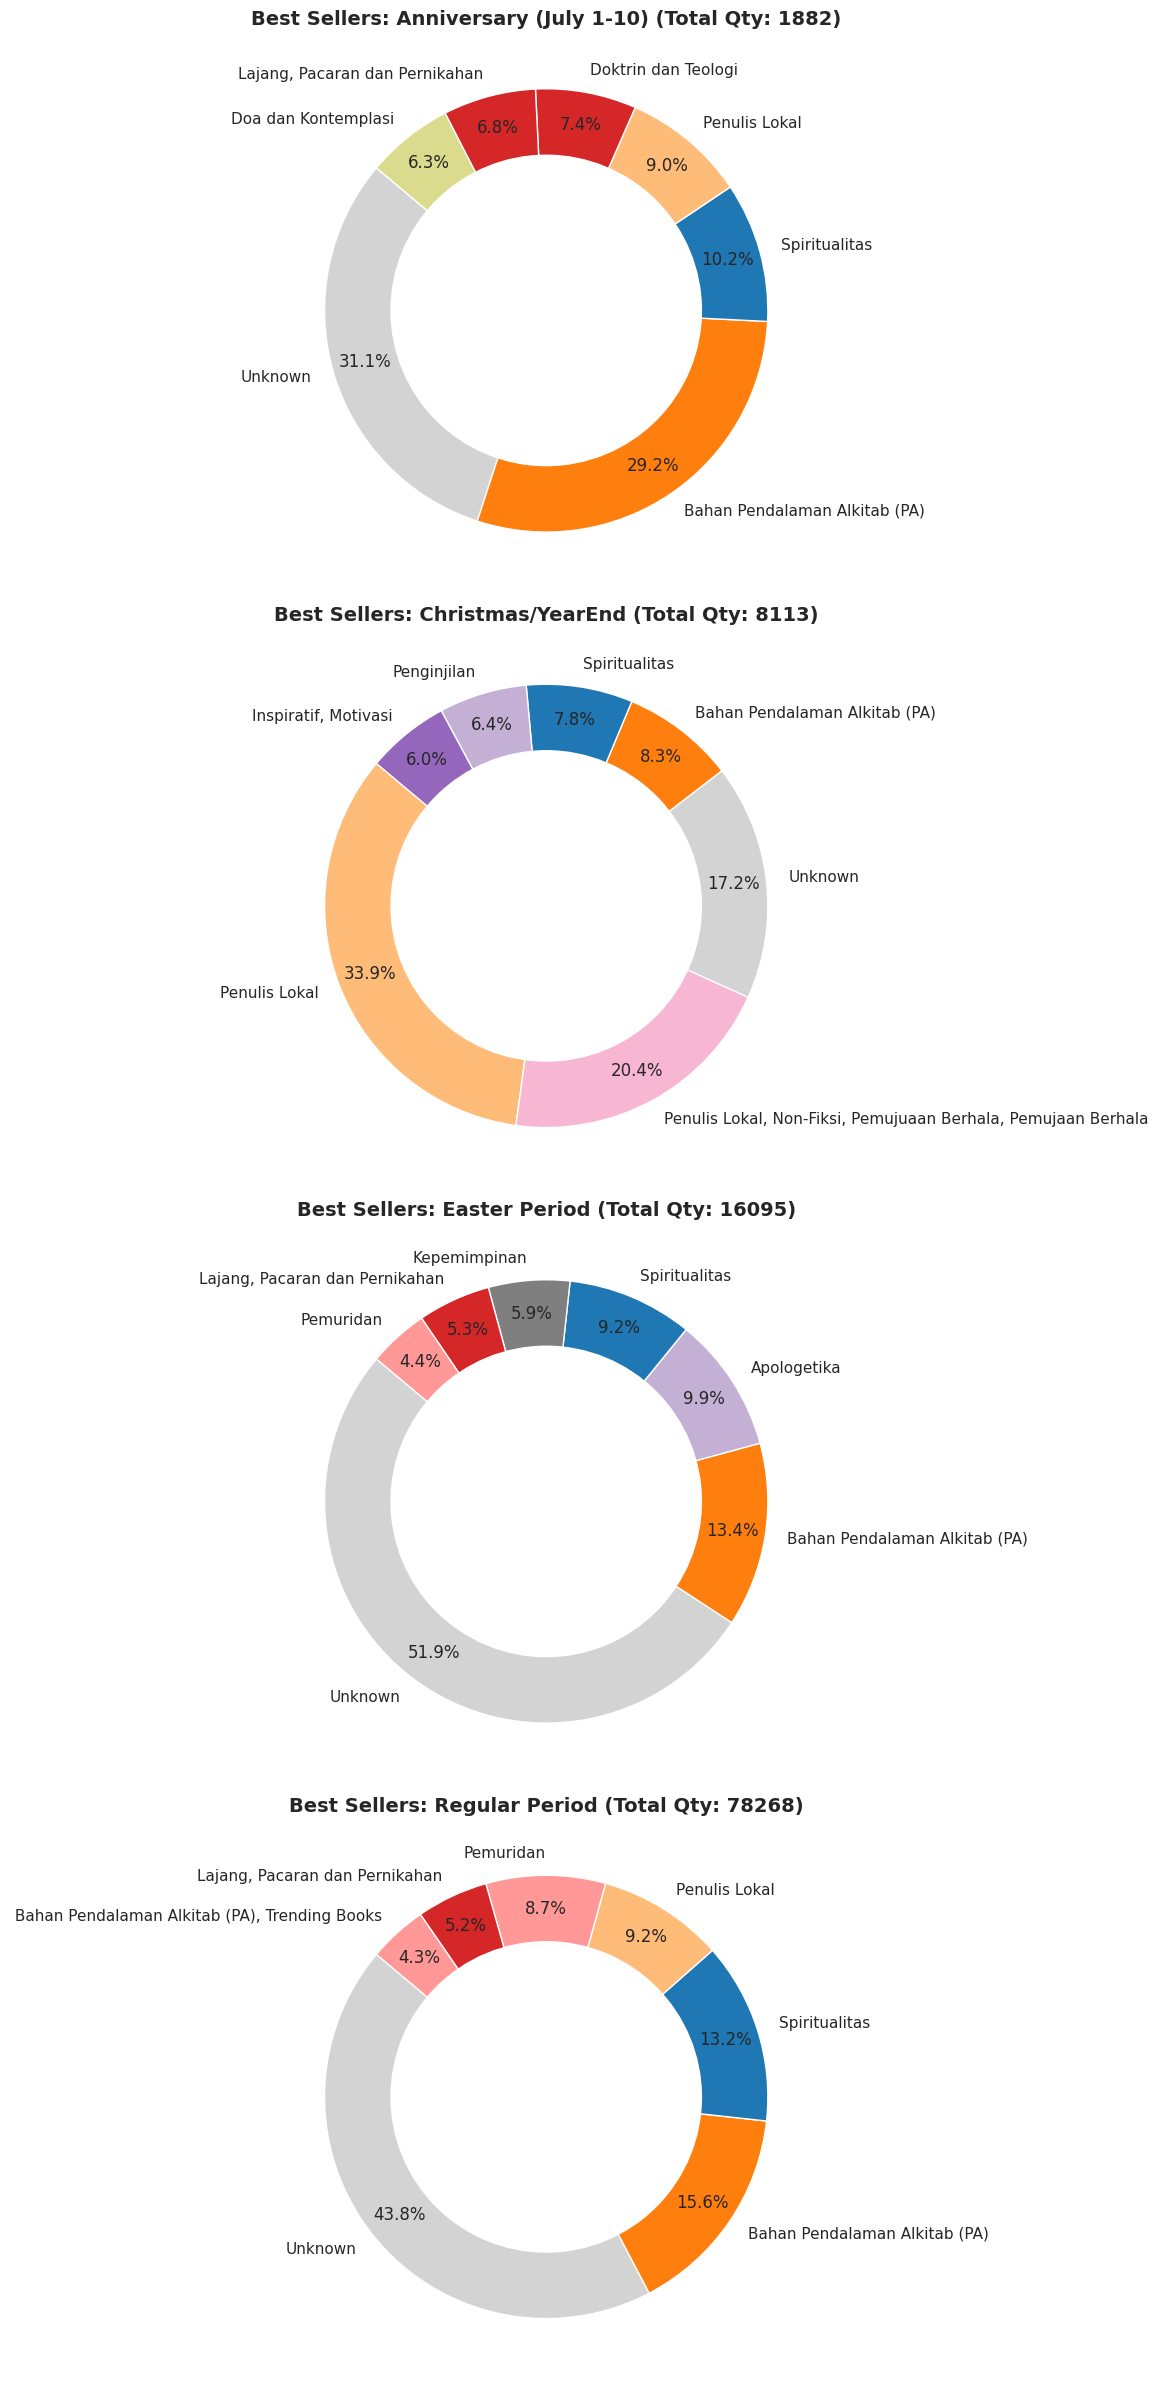

In [47]:
if df is not None:
    holidays = df['Holiday'].unique()

    unique_genres = df['Genre'].unique() # genre unknown jadiin grey aja
    palette = sns.color_palette("tab20", len(unique_genres))
    color_map = dict(zip(unique_genres, palette))
    color_map['Unknown'] = '#D3D3D3'

    fig, axes = plt.subplots(len(holidays), 1, figsize=(10, 6 * len(holidays)))
    if len(holidays) == 1: axes = [axes] # Handle single case

    for i, holiday in enumerate(sorted(holidays)):
        # Get Data
        subset = df[df['Holiday'] == holiday]
        genre_counts = subset.groupby('Genre')['Jml'].sum().sort_values(ascending=False)

        # top 7
        if len(genre_counts) > 7:
            others = genre_counts[7:].sum()
            genre_counts = genre_counts[:7]

        # Plot
        ax = axes[i]
        colors = [color_map.get(g, '#D3D3D3') for g in genre_counts.index]

        wedges, texts, autotexts = ax.pie(
            genre_counts, labels=genre_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.85
        )

        # buat jadi donut
        centre_circle = plt.Circle((0,0),0.70,fc='white')
        ax.add_artist(centre_circle)

        ax.set_title(f"Best Sellers: {holiday} (Total Qty: {int(subset['Jml'].sum())})", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

## Revenue Chart
pendapatan per bulan

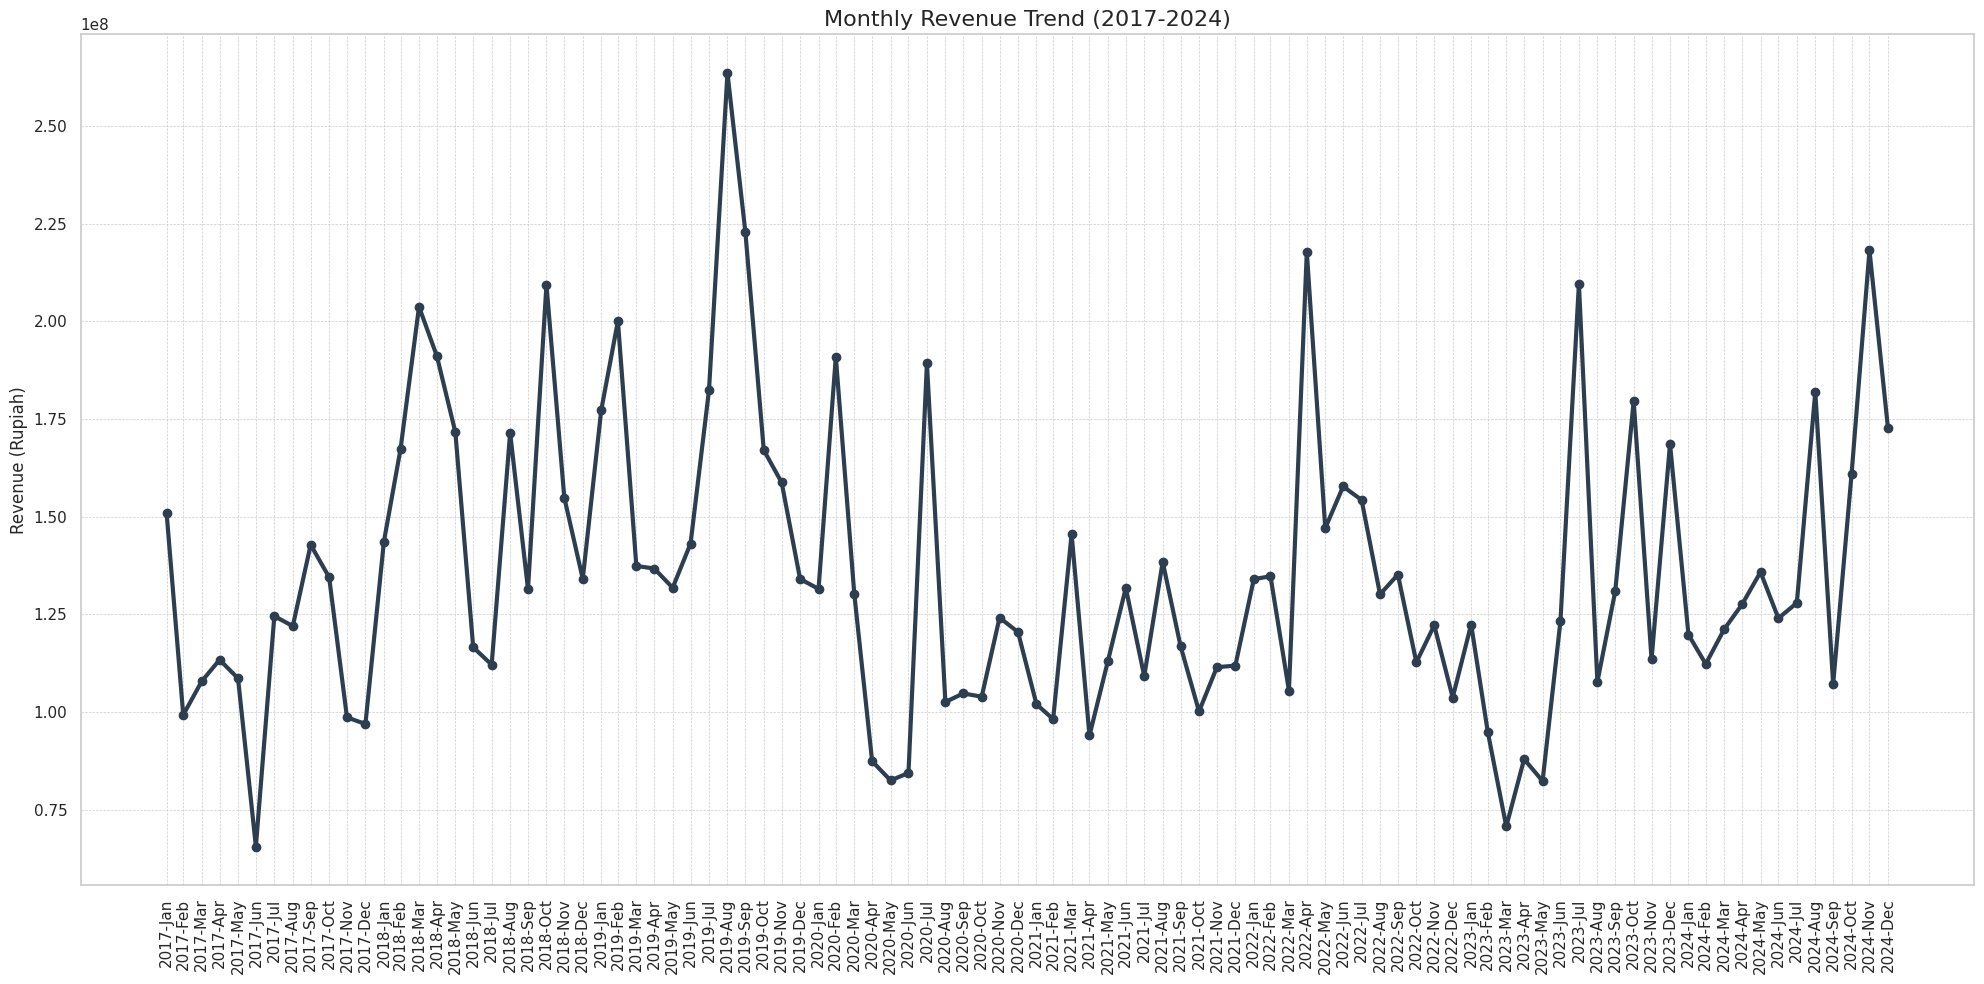

In [48]:
if df is not None:
  monthly_rev = df.resample('M', on='Tgl. Trans.')['Grand Total (Rp)'].sum()

  plt.figure(figsize=(20, 10))
  plt.plot(monthly_rev.index, monthly_rev.values, marker='o', linewidth=3, color='#2c3e50')

  # Formatting X-Axis
  plt.xticks(monthly_rev.index, [x.strftime('%Y-%b') for x in monthly_rev.index], rotation=90)
  plt.grid(True, which='both', linestyle='--', linewidth=0.5)
  plt.title('Monthly Revenue Trend (2017-2024)', fontsize=16)
  plt.ylabel('Revenue (Rupiah)')
  plt.tight_layout()
  plt.show()

## Payment Terms Analysis

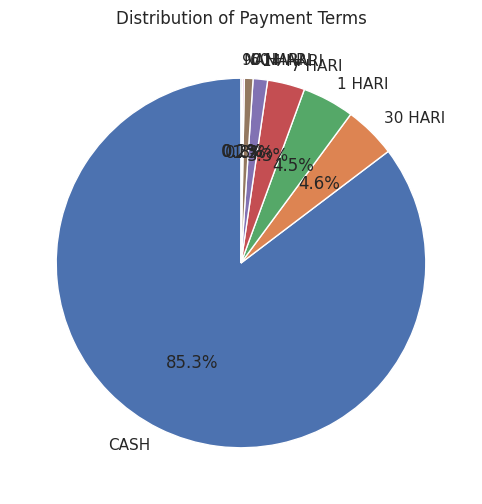

Average Transaction Value by Payment Term (Do credit terms lead to bigger buys?):
Syarat_Clean
90 HARI    Rp 4,606,908
7 HARI     Rp 2,842,518
60 HARI    Rp 1,256,590
14 HARI    Rp 1,197,307
21 HARI    Rp 1,066,697
45 HARI    Rp 1,035,375
30 HARI      Rp 983,088
1 HARI       Rp 856,098
CASH         Rp 287,290
NAN           Rp 81,311
Name: Grand Total (Rp), dtype: object


In [49]:
if df is not None:
    if 'Syarat Bayar.' in df.columns:
        df['Syarat_Clean'] = df['Syarat Bayar.'].astype(str).str.upper().str.strip()

        # Distribusi
        pay_counts = df['Syarat_Clean'].value_counts().head(8)
        plt.figure(figsize=(10, 6))
        plt.pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', startangle=90)
        plt.title('Distribution of Payment Terms')
        plt.show()

        # Apakah credit terms mendorong pembelian lebih?
        avg_trans_val = df.groupby('Syarat_Clean')['Grand Total (Rp)'].mean().sort_values(ascending=False).head(10)
        print("Average Transaction Value by Payment Term (Do credit terms lead to bigger buys?):")
        print(avg_trans_val.apply(lambda x: f"Rp {x:,.0f}"))

## Season Cycle Prediction using Polynomial Regression
Pakai degree 4

### Aggregate Sales tiap bulan di setiap taun

In [50]:
if df is not None:
  monthly_cycle = df.groupby('Month')['Jml'].mean().reset_index()
  X = monthly_cycle[['Month']]
  y = monthly_cycle['Jml']

### Buat Polynomial Model degree 4

In [51]:
if df is not None:
  poly = PolynomialFeatures(degree=4)
  X_poly = poly.fit_transform(X)
  model = LinearRegression()
  model.fit(X_poly, y)

Make smooth curve

In [52]:
if df is not None:
  X_seq = np.linspace(1, 12, 100).reshape(-1, 1)
  y_pred = model.predict(poly.fit_transform(X_seq))

### Buat Plot nya

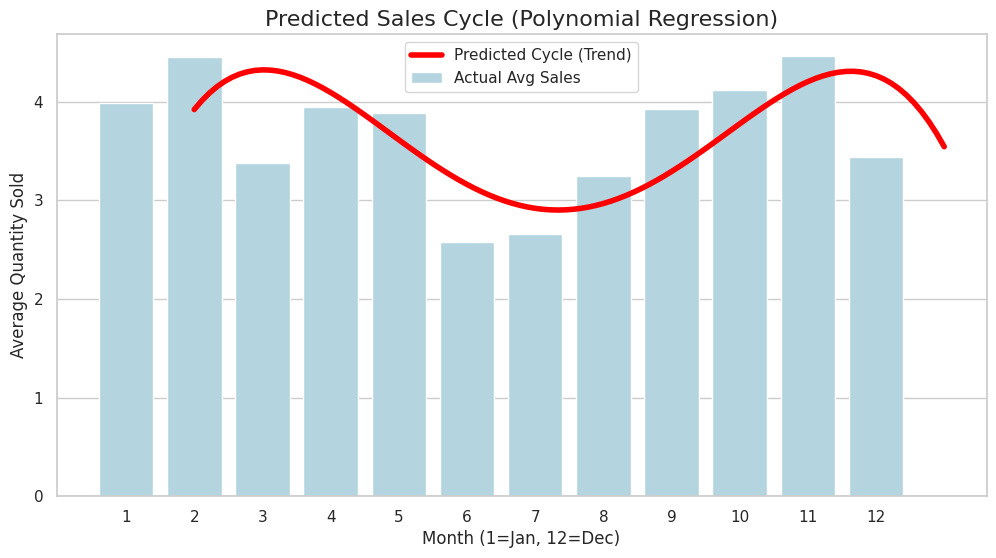

In [53]:
if df is not None:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=monthly_cycle, x='Month', y='Jml', color='lightblue', label='Actual Avg Sales')
    plt.plot(X_seq, y_pred, color='red', linewidth=4, label='Predicted Cycle (Trend)')

    plt.title('Predicted Sales Cycle (Polynomial Regression)', fontsize=16)
    plt.xlabel('Month (1=Jan, 12=Dec)')
    plt.ylabel('Average Quantity Sold')
    plt.legend()
    plt.show()

## Hierarchical Clustering Genre Family Tree

### Genre vs Month

In [54]:
if df is not None:
  genre_profile = df.pivot_table(index='Genre', columns='Month', values='Jml', aggfunc='sum', fill_value=0)

### Filter small genres & Normalize
biar tree tidak kotor

In [55]:
if df is not None:
  genre_profile = genre_profile[genre_profile.sum(axis=1) > 100]

compare patterns bukan volume

In [56]:
if df is not None:
  genre_norm = genre_profile.div(genre_profile.sum(axis=1), axis=0)

### Clustering

In [57]:
if df is not None:
  Z = linkage(genre_norm, method='ward')

### Plot

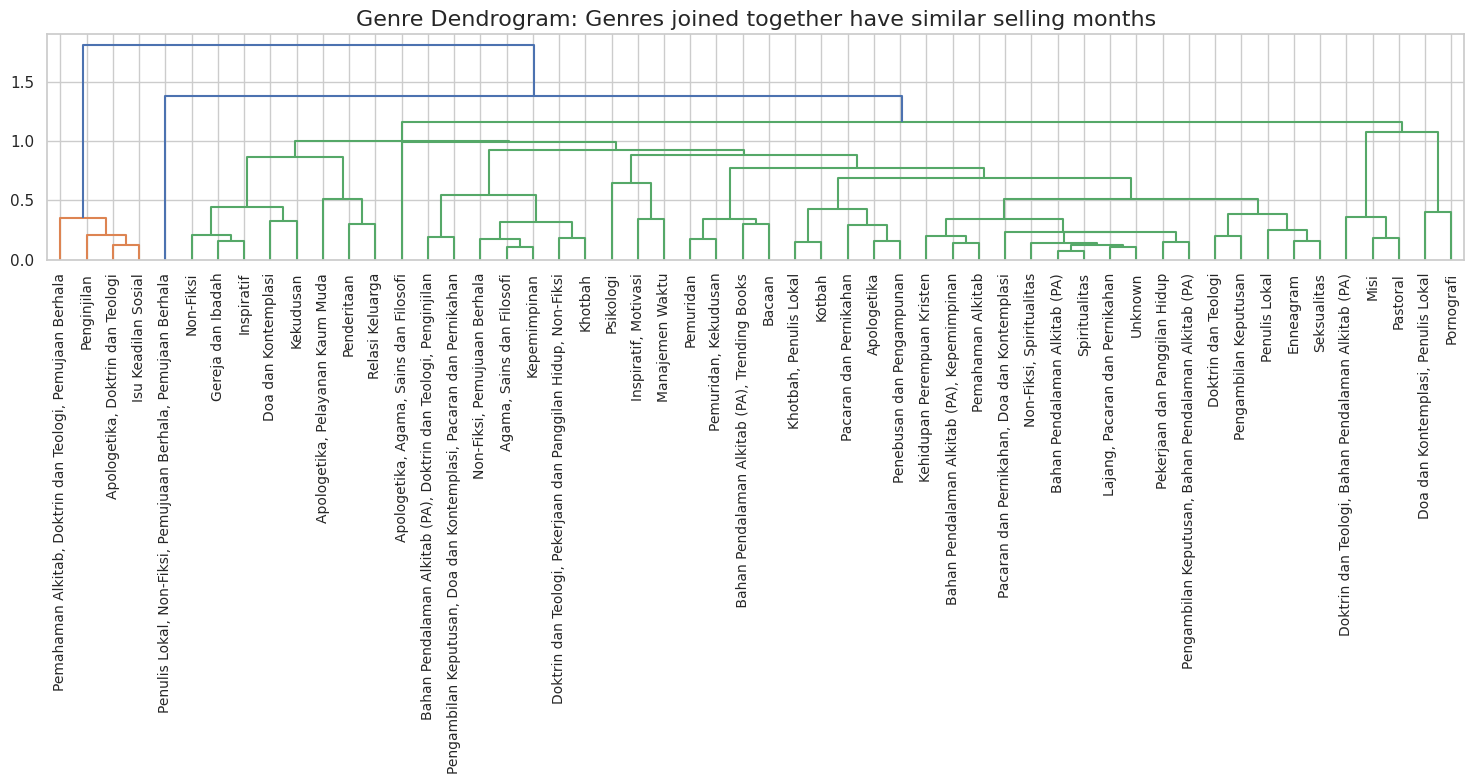

In [58]:
if df is not None:
  plt.figure(figsize=(15, 8))
  dendrogram(Z, labels=genre_norm.index, leaf_rotation=90, leaf_font_size=10)
  plt.title('Genre Dendrogram: Genres joined together have similar selling months', fontsize=16)
  plt.tight_layout()
  plt.show()